The notebook presents examples to refresh the basics of neural network (Chapters 1 and 2) and getting started with training a graph neural network (Chapters 3-5). Topics covered:

*   Representing adjacency (Chapter 0)
*   Simple classifier (Chapter 1)
*   Classifier with real data (Chapter 2)
*   Create some graph data (Chapter 3)
*   Train a multi-layer perceptron (Chapter 4)
*   Train a simple graph neural network (Chapter 5)

# Chapter 0: Representing adjacency

In [ ]:
import networkx as nx
G = nx.Graph() #nx.DiGraph()
G.add_edge(1, 2)
G.add_edge(1, 3)
G.add_edge(4, 2)
G.add_edge(2, 5)

pos = {1: (0, 1), 2: (0, 0), 3: (1, 1), 4: (0.5, 0.5), 5: (1.5, 0.5)}

options = {
    "font_size": 25,
    "node_size": 1000,
    "node_color": "white",
    "edgecolors": "black",
    "linewidths": 5,
    "width": 5,

}
nx.draw_networkx(G, pos, **options, arrows=True)

In [ ]:
A = nx.adjacency_matrix(G)
A.toarray()

In [ ]:
from scipy.sparse import coo_array
import numpy as np
u = coo_array(A.toarray()).coords
np.asarray(u)

# Chapter 1: Very simple classifier

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

xs = np.arange(-2, 12, 1)
xs

def f (x):
  return [1 if i<5 else 0 for i in x]

def generate_examples(input_list):

   plt.plot(input_list, f(input_list))
   plt.show()
   return f(input_list)

print(xs, "\n", generate_examples(xs))

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

x = torch.tensor([[1], [2], [3.0], [7], [8], [11]], dtype=torch.float)
y = torch.tensor([[1], [1], [1], [0], [0], [0]], dtype=torch.float)
x, y, x.shape, y.shape

In [ ]:
class NeuralNetwork(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer = nn.Linear(1, 1, bias=True)

  def forward(self, x):
    return self.layer(x)

In [ ]:
import matplotlib.pyplot as plt

losses = []

## training
def train_model(model, x, y, epochs=200):

  ## loss function
  bce = nn.BCEWithLogitsLoss() #nn.BCELoss()

  ## optimizer algorithm  (one alternative to SGD is Adam)
  optimizer = optim.Adam(model.parameters(), lr=0.06)

  for epoch in range(epochs):
      model.train() # signal that we are in training mode - should be added after each epoch

      # forward pass: compute predicted targets by passing inputs to the model
      logits = model(x)

      # loss: compute loss according to the selected loss function
      loss = bce(logits, y)

      # reset gradient (as we are not training a recurrent neural network)
      optimizer.zero_grad()

      # backward pass: compute gradient of the loss with respect to model parameters
      loss.backward()

      # call the step function on an Optimizer to make an update of weights and biases
      optimizer.step()

      # save loss value for later
      losses.append(loss.item())

      preds = (torch.sigmoid(logits) > 0.5).float()
      train_accuracy = (preds == y).float().mean()

      print('Epoch: %d | Loss: %.4f | Train acc: %.2f}' %(epoch, loss.item(), train_accuracy))

def show_loss(losses):
  # plotting the loss evolution during training
  plt.plot(losses)
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.title('Training Loss')
  plt.show()

nn101 = NeuralNetwork()
train_model(nn101, x, y)
show_loss(losses)

In [ ]:
def evaluate_model(model, test_value):

  model.eval() # say that the model is now in evaluation mode

  ## test the model
  sample = torch.tensor([test_value], dtype=torch.float)
  logits = model(sample)
  predicted = torch.round(torch.sigmoid(logits)) # alternative, use preds = torch.sigmoid(logits) > 0.5 => returns true/false
  print("Original values: ", 1 if test_value <5 else 0)
  print("Predicted values: ", predicted.item())

evaluate_model(nn101, -2)

In [ ]:
# adapted from https://psrivasin.medium.com/plotting-decision-boundaries-using-numpy-and-matplotlib-f5613d8acd19
# plotting decision boundaries using numpy and Matplotlib

def plot_decision_boundary(model, inputs, targets):

   # the min and maximum x and y coordinates for our data
   x_min, x_max = inputs.min() - 0.1, inputs.max() + 0.1
   y_min, y_max = targets.min() - 0.1, targets.max() + 0.1

   # create a rectangular grid of points inside these boundaries
   n_grid_points = 1000
   xx, yy = np.meshgrid(np.linspace(x_min, x_max, n_grid_points), np.linspace(y_min, y_max, n_grid_points))

   # prepare input for the model
   x_in = torch.tensor(xx.ravel(), dtype=torch.float32).unsqueeze(1)

   # prediction using the model
   logits = model(x_in)
   preds = (torch.sigmoid(logits) > 0.5).float()

   # reshape y_pred to be the same shape as xx, in order to use the contour function
   y_pred = preds.reshape(xx.shape)

   plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7 )
   plt.scatter(inputs, targets, c=targets, cmap=plt.cm.RdYlBu)
   plt.xlim(xx.min(), xx.max())
   plt.ylim(yy.min(), yy.max())

plot_decision_boundary(nn101, x, y)

# Chapter 2: Classifier with real data

In [ ]:
my_url = "https://raw.githubusercontent.com/aurioldegbelo/geoid2025/refs/heads/main/data/bundeslaender.csv"

import pandas as pd

df = pd.read_csv(my_url)
df

In [ ]:
df['label'] = df.eval("area < 20000").astype(int)
df

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

In [ ]:
class NeuralNetwork(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer = nn.Linear(1, 1, bias=True)

  def forward(self, x):
    return self.layer(x)

In [ ]:
inputs = torch.tensor(df['area'].values, dtype=torch.float).unsqueeze(1)
labels = torch.tensor(df['label'], dtype=torch.float).unsqueeze(1)

inputs, labels, inputs.shape, labels.shape

In [ ]:
normalized_inputs = (inputs - torch.min(inputs)) / (torch.max(inputs) - torch.min(inputs))
normalized_inputs

Effect of learning rate and optimizer

In [ ]:
import matplotlib.pyplot as plt

losses = []
accuracies = []

## training
def train_model(model, features, targets, epochs=1000):

  ## loss function
  bce = nn.BCEWithLogitsLoss()

  ## optimizer algorithm  (one alternative to SGD is Adam)
  optimizer = optim.SGD(model.parameters(), lr=0.001) # 0.03

  for epoch in range(epochs):
      model.train() # signal that we are in training mode - should be added after each epoch

      # forward pass: compute predicted targets by passing inputs to the model
      logits = model(features)

      #print(logits, y)

      # loss: compute loss according to the selected loss function
      loss = bce(logits, targets)

      # reset gradient (as we are not training a recurrent neural network)
      optimizer.zero_grad()

      # backward pass: compute gradient of the loss with respect to model parameters
      loss.backward()

      # call the step function on an Optimizer to make an update of weights and biases
      optimizer.step()

      preds = (torch.sigmoid(logits) > 0.5).float()
      train_accuracy = (preds == targets).float().mean()

      # save loss value for later
      losses.append(loss.item())
      accuracies.append(train_accuracy)
      if (epoch + 1) % 10 == 0 or epoch == 0:
        print('Epoch: %d | Loss: %.4f  Train acc: %.2f}' %(epoch, loss.item(), train_accuracy))

  plt.plot(losses)
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.title('Training Loss')
  plt.show()

  plt.plot(accuracies)
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.title('Training accuracy')
  plt.show()

nn102 = NeuralNetwork()
print(nn102)
train_model(nn102, inputs, labels) # change the learning rate from 0.1 to 0.01 and to 0.001 to see the effect // and then from Adam to SDG (0.01 vs 0.001)

A more complex function to learn

In [ ]:
u = [[a, b] for a, b in zip(df['area'], df['population'])]
inputs2 = torch.tensor(u, dtype=torch.float)

df['label'] = df.eval("area < 20000 & population > 1000000").astype(int)
labels2 = torch.tensor(df['label'], dtype=torch.float).unsqueeze(1)

inputs2, labels2, inputs2.shape, labels2.shape

In [ ]:
df

In [ ]:
normalized_inputs2 = (inputs2 - torch.min(inputs2)) / (torch.max(inputs2) - torch.min(inputs2))
normalized_inputs2

In [ ]:
X = inputs2.numpy()
y = labels2.numpy()

fig, ax = plt.subplots()

scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)

legend = ax.legend(*scatter.legend_elements(), title="Classes")
ax.add_artist(legend)

plt.title('Data: Area vs Population')
plt.xlabel('area')
plt.ylabel('population')
plt.show()

In [ ]:
X = normalized_inputs2.numpy()
y = labels2.numpy()

fig, ax = plt.subplots()

scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)

legend = ax.legend(*scatter.legend_elements(), title="Classes")
ax.add_artist(legend)

plt.title('Data: Area vs Population')
plt.xlabel('area')
plt.ylabel('population')
plt.show()

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# simple feedforward neural network
class MultiLayerPerceptron(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(2, 100),
            nn.ReLU(),
            nn.Linear(100, 100),
            nn.ReLU(),
            nn.Linear(100, 1),
        )

    def forward(self, x):
        return self.fc(x)

Effect of normalization

In [ ]:
import matplotlib.pyplot as plt

losses = []
accuracies = []

## training
def train_model(model, x, y, epochs=1000):

  ## loss function
  bce = nn.BCEWithLogitsLoss()

  ## optimizer algorithm  (one alternative to SGD is Adam)
  optimizer = optim.Adam(model.parameters(), lr=0.01)

  for epoch in range(epochs):
      model.train() # signal that we are in training mode - should be added after each epoch

      # forward pass: compute predicted targets by passing inputs to the model
      logits = model(x)

      # loss: compute loss according to the selected loss function
      loss = bce(logits, y)

      # reset gradient (as we are not training a recurrent neural network)
      optimizer.zero_grad()

      # backward pass: compute gradient of the loss with respect to model parameters
      loss.backward()

      # call the step function on an Optimizer to make an update of weights and biases
      optimizer.step()

      predicted = torch.round(torch.sigmoid(logits))
      preds = torch.sigmoid(logits) > 0.5
      train_accuracy = (preds == y).float().mean()

      # save loss value for later
      losses.append(loss.item())
      accuracies.append(train_accuracy)
      if (epoch + 1) % 10 == 0 or epoch == 0:
        print('Epoch: %d | Loss: %.4f  Train acc: %.2f}' %(epoch, loss.item(), train_accuracy))

  plt.plot(losses)
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.title('Training Loss')
  plt.show()

  plt.plot(accuracies)
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.title('Training accuracy')
  plt.show()

# Instantiate the model
nn103 = MultiLayerPerceptron()
print(nn103)
train_model(nn103, normalized_inputs2, labels2) # use normalized inputs to see the effect

In [ ]:
# adapted from https://psrivasin.medium.com/plotting-decision-boundaries-using-numpy-and-matplotlib-f5613d8acd19
# plotting decision boundaries using numpy and Matplotlib

def plot_decision_boundary(model, inputs, targets):

   # the min and maximum x and y coordinates for our data
   x_min, x_max = inputs[:, 0].min() - 0.0001, inputs[:, 0].max() + 0.0001
   y_min, y_max = inputs[:, 1].min() - 0.1, inputs[:, 1].max() + 0.1

   # create a rectangular grid of points inside these boundaries
   n_grid_points = 100
   xx, yy = np.meshgrid(np.linspace(x_min, x_max, n_grid_points), np.linspace(y_min, y_max, n_grid_points))

   # prepare input for the model
   x_in = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

   #print(x_in, x_in.shape)
   # prediction using the model
   logits = model(x_in)
   predicted = torch.round(torch.sigmoid(logits)) # convert logits to a probability
   preds = torch.sigmoid(logits) > 0.5 # convert a probability to a label

   # reshape y_pred to be the same shape as xx, in order to use the contour function
   y_pred = preds.reshape(xx.shape)

   plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7 )
   plt.scatter(inputs[:, 0], inputs[:, 1], c=targets, cmap=plt.cm.RdYlBu)
   plt.xlim(xx.min(), xx.max())
   plt.ylim(yy.min(), yy.max())

plot_decision_boundary(nn103, normalized_inputs2, labels2)

# Chapter 3: Graph data preparation



In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# List of European countries and their land borders (based on CIA World Factbook and Wikipedia)
# Note: Generated with ChatGPT, checked afterwards for correctness.
borders = {
    "Albania": ["Greece", "Kosovo", "Montenegro", "North Macedonia"],
    "Andorra": ["France", "Spain"],
    "Austria": ["Czechia", "Germany", "Hungary", "Italy", "Liechtenstein", "Slovakia", "Slovenia", "Switzerland"],
    "Belarus": ["Latvia", "Lithuania", "Poland", "Russia", "Ukraine"],
    "Belgium": ["France", "Germany", "Luxembourg", "Netherlands"],
    "Bosnia and Herzegovina": ["Croatia", "Montenegro", "Serbia"],
    "Bulgaria": ["Greece", "North Macedonia", "Romania", "Serbia", "Turkey"],
    "Croatia": ["Bosnia and Herzegovina", "Hungary", "Montenegro", "Serbia", "Slovenia"],
    "Czechia": ["Austria", "Germany", "Poland", "Slovakia"],
    "Denmark": ["Germany"],
    "Estonia": ["Latvia", "Russia"],
    "Finland": ["Norway", "Russia", "Sweden"],
    "France": ["Andorra", "Belgium", "Germany", "Italy", "Luxembourg", "Monaco", "Spain", "Switzerland"],
    "Germany": ["Austria", "Belgium", "Czechia", "Denmark", "France", "Luxembourg", "Netherlands", "Poland", "Switzerland"],
    "Gibraltar": ["Spain"],
    "Greece": ["Albania", "Bulgaria", "North Macedonia", "Turkey"],
    "Hungary": ["Austria", "Croatia", "Romania", "Serbia", "Slovakia", "Slovenia", "Ukraine"],
    "Iceland": [],
    "Ireland": ["United Kingdom"],
    "Italy": ["Austria", "France", "San Marino", "Slovenia", "Switzerland", "Vatican City"],
    "Kosovo": ["Albania", "Montenegro", "North Macedonia", "Serbia"],
    "Latvia": ["Belarus", "Estonia", "Lithuania", "Russia"],
    "Liechtenstein": ["Austria", "Switzerland"],
    "Lithuania": ["Belarus", "Latvia", "Poland", "Russia"],
    "Luxembourg": ["Belgium", "France", "Germany"],
    "Malta": [],
    "Moldova": ["Romania", "Ukraine"],
    "Monaco": ["France"],
    "Montenegro": ["Albania", "Bosnia and Herzegovina", "Croatia", "Kosovo", "Serbia"],
    "Netherlands": ["Belgium", "Germany"],
    "North Macedonia": ["Albania", "Bulgaria", "Greece", "Kosovo", "Serbia"],
    "Norway": ["Finland", "Russia", "Sweden"],
    "Poland": ["Belarus", "Czechia", "Germany", "Lithuania", "Russia", "Slovakia", "Ukraine"],
    "Portugal": ["Spain"],
    "Romania": ["Bulgaria", "Hungary", "Moldova", "Serbia", "Ukraine"],
    "Russia": ["Belarus", "Estonia", "Finland", "Latvia", "Lithuania", "Norway", "Poland", "Ukraine"],
    "San Marino": ["Italy"],
    "Serbia": ["Bosnia and Herzegovina", "Bulgaria", "Croatia", "Hungary", "Kosovo", "Montenegro", "North Macedonia", "Romania"],
    "Slovakia": ["Austria", "Czechia", "Hungary", "Poland", "Ukraine"],
    "Slovenia": ["Austria", "Croatia", "Hungary", "Italy"],
    "Spain": ["Andorra", "France", "Gibraltar", "Portugal"],
    "Sweden": ["Finland", "Norway"],
    "Switzerland": ["Austria", "France", "Germany", "Italy", "Liechtenstein"],
    "Turkey": ["Bulgaria", "Greece"],
    "Ukraine": ["Belarus", "Hungary", "Moldova", "Poland", "Romania", "Russia", "Slovakia"],
    "United Kingdom": ["Ireland"],
    "Vatican City": ["Italy"]
}

# Create a sorted list of countries
countries = sorted(borders.keys())
print(len(countries))

# Initialize adjacency matrix
adj_matrix = pd.DataFrame(0, index=countries, columns=countries)

# Fill the matrix
for country, neighbors in borders.items():
    print(country, neighbors)
    for neighbor in neighbors:
        adj_matrix.loc[country, neighbor] = 1
        adj_matrix.loc[neighbor, country] = 1  # ensure symmetry

adj_matrix

47
Albania ['Greece', 'Kosovo', 'Montenegro', 'North Macedonia']
Andorra ['France', 'Spain']
Austria ['Czechia', 'Germany', 'Hungary', 'Italy', 'Liechtenstein', 'Slovakia', 'Slovenia', 'Switzerland']
Belarus ['Latvia', 'Lithuania', 'Poland', 'Russia', 'Ukraine']
Belgium ['France', 'Germany', 'Luxembourg', 'Netherlands']
Bosnia and Herzegovina ['Croatia', 'Montenegro', 'Serbia']
Bulgaria ['Greece', 'North Macedonia', 'Romania', 'Serbia', 'Turkey']
Croatia ['Bosnia and Herzegovina', 'Hungary', 'Montenegro', 'Serbia', 'Slovenia']
Czechia ['Austria', 'Germany', 'Poland', 'Slovakia']
Denmark ['Germany']
Estonia ['Latvia', 'Russia']
Finland ['Norway', 'Russia', 'Sweden']
France ['Andorra', 'Belgium', 'Germany', 'Italy', 'Luxembourg', 'Monaco', 'Spain', 'Switzerland']
Germany ['Austria', 'Belgium', 'Czechia', 'Denmark', 'France', 'Luxembourg', 'Netherlands', 'Poland', 'Switzerland']
Gibraltar ['Spain']
Greece ['Albania', 'Bulgaria', 'North Macedonia', 'Turkey']
Hungary ['Austria', 'Croatia', 

,Albania,Andorra,Austria,Belarus,Belgium,Bosnia and Herzegovina,Bulgaria,Croatia,Czechia,Denmark,...,Serbia,Slovakia,Slovenia,Spain,Sweden,Switzerland,Turkey,Ukraine,United Kingdom,Vatican City
Albania,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Andorra,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
Austria,0,0,0,0,0,0,0,0,1,0,...,0,1,1,0,0,1,0,0,0,0
Belarus,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
Belgium,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Bosnia and Herzegovina,0,0,0,0,0,0,0,1,0,0,...,1,0,0,0,0,0,0,0,0,0
Bulgaria,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,1,0,0,0
Croatia,0,0,0,0,0,1,0,0,0,0,...,1,0,1,0,0,0,0,0,0,0
Czechia,0,0,1,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
Denmark,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
borders["Sweden"]

['Finland', 'Norway']

In [ ]:
# Values in millions
populations = {
    "Albania": 2.8,
    "Andorra": 0.08,
    "Austria": 9.1,
    "Belarus": 9.2,
    "Belgium": 11.6,
    "Bosnia and Herzegovina": 3.2,
    "Bulgaria": 6.5,
    "Croatia": 3.9,
    "Czechia": 10.8,
    "Denmark": 5.9,
    "Estonia": 1.3,
    "Finland": 5.5,
    "France": 68.0,
    "Germany": 83.3,
    "Greece": 10.1,
    "Hungary": 9.7,
    "Iceland": 0.39,
    "Ireland": 5.1,
    "Italy": 59.0,
    "Kosovo": 1.8,
    "Latvia": 1.9,
    "Liechtenstein": 0.04,
    "Lithuania": 2.6,
    "Luxembourg": 0.67,
    "Malta": 0.53,
    "Moldova": 2.6,
    "Monaco": 0.04,
    "Montenegro": 0.62,
    "Netherlands": 17.8,
    "North Macedonia": 2.0,
    "Norway": 5.5,
    "Poland": 37.5,
    "Portugal": 10.3,
    "Romania": 19.0,
    "Russia": 143.4,  # European part only; rough estimate
    "San Marino": 0.03,
    "Serbia": 6.6,
    "Slovakia": 5.4,
    "Slovenia": 2.1,
    "Spain": 47.6,
    "Sweden": 10.6,
    "Switzerland": 8.7,
    "Turkey": 85.0,  # European part only ~15 million; here, use total for simplicity
    "Ukraine": 35.0,  # Recent estimate post-conflict
    "United Kingdom": 68.2,
    "Vatican City": 0.0008,
    "Gibraltar": 0.03
}

In [ ]:
def get_label(country):
    return (1 if populations[country] > 20 else 0)

In [ ]:
get_label("Gibraltar")

0

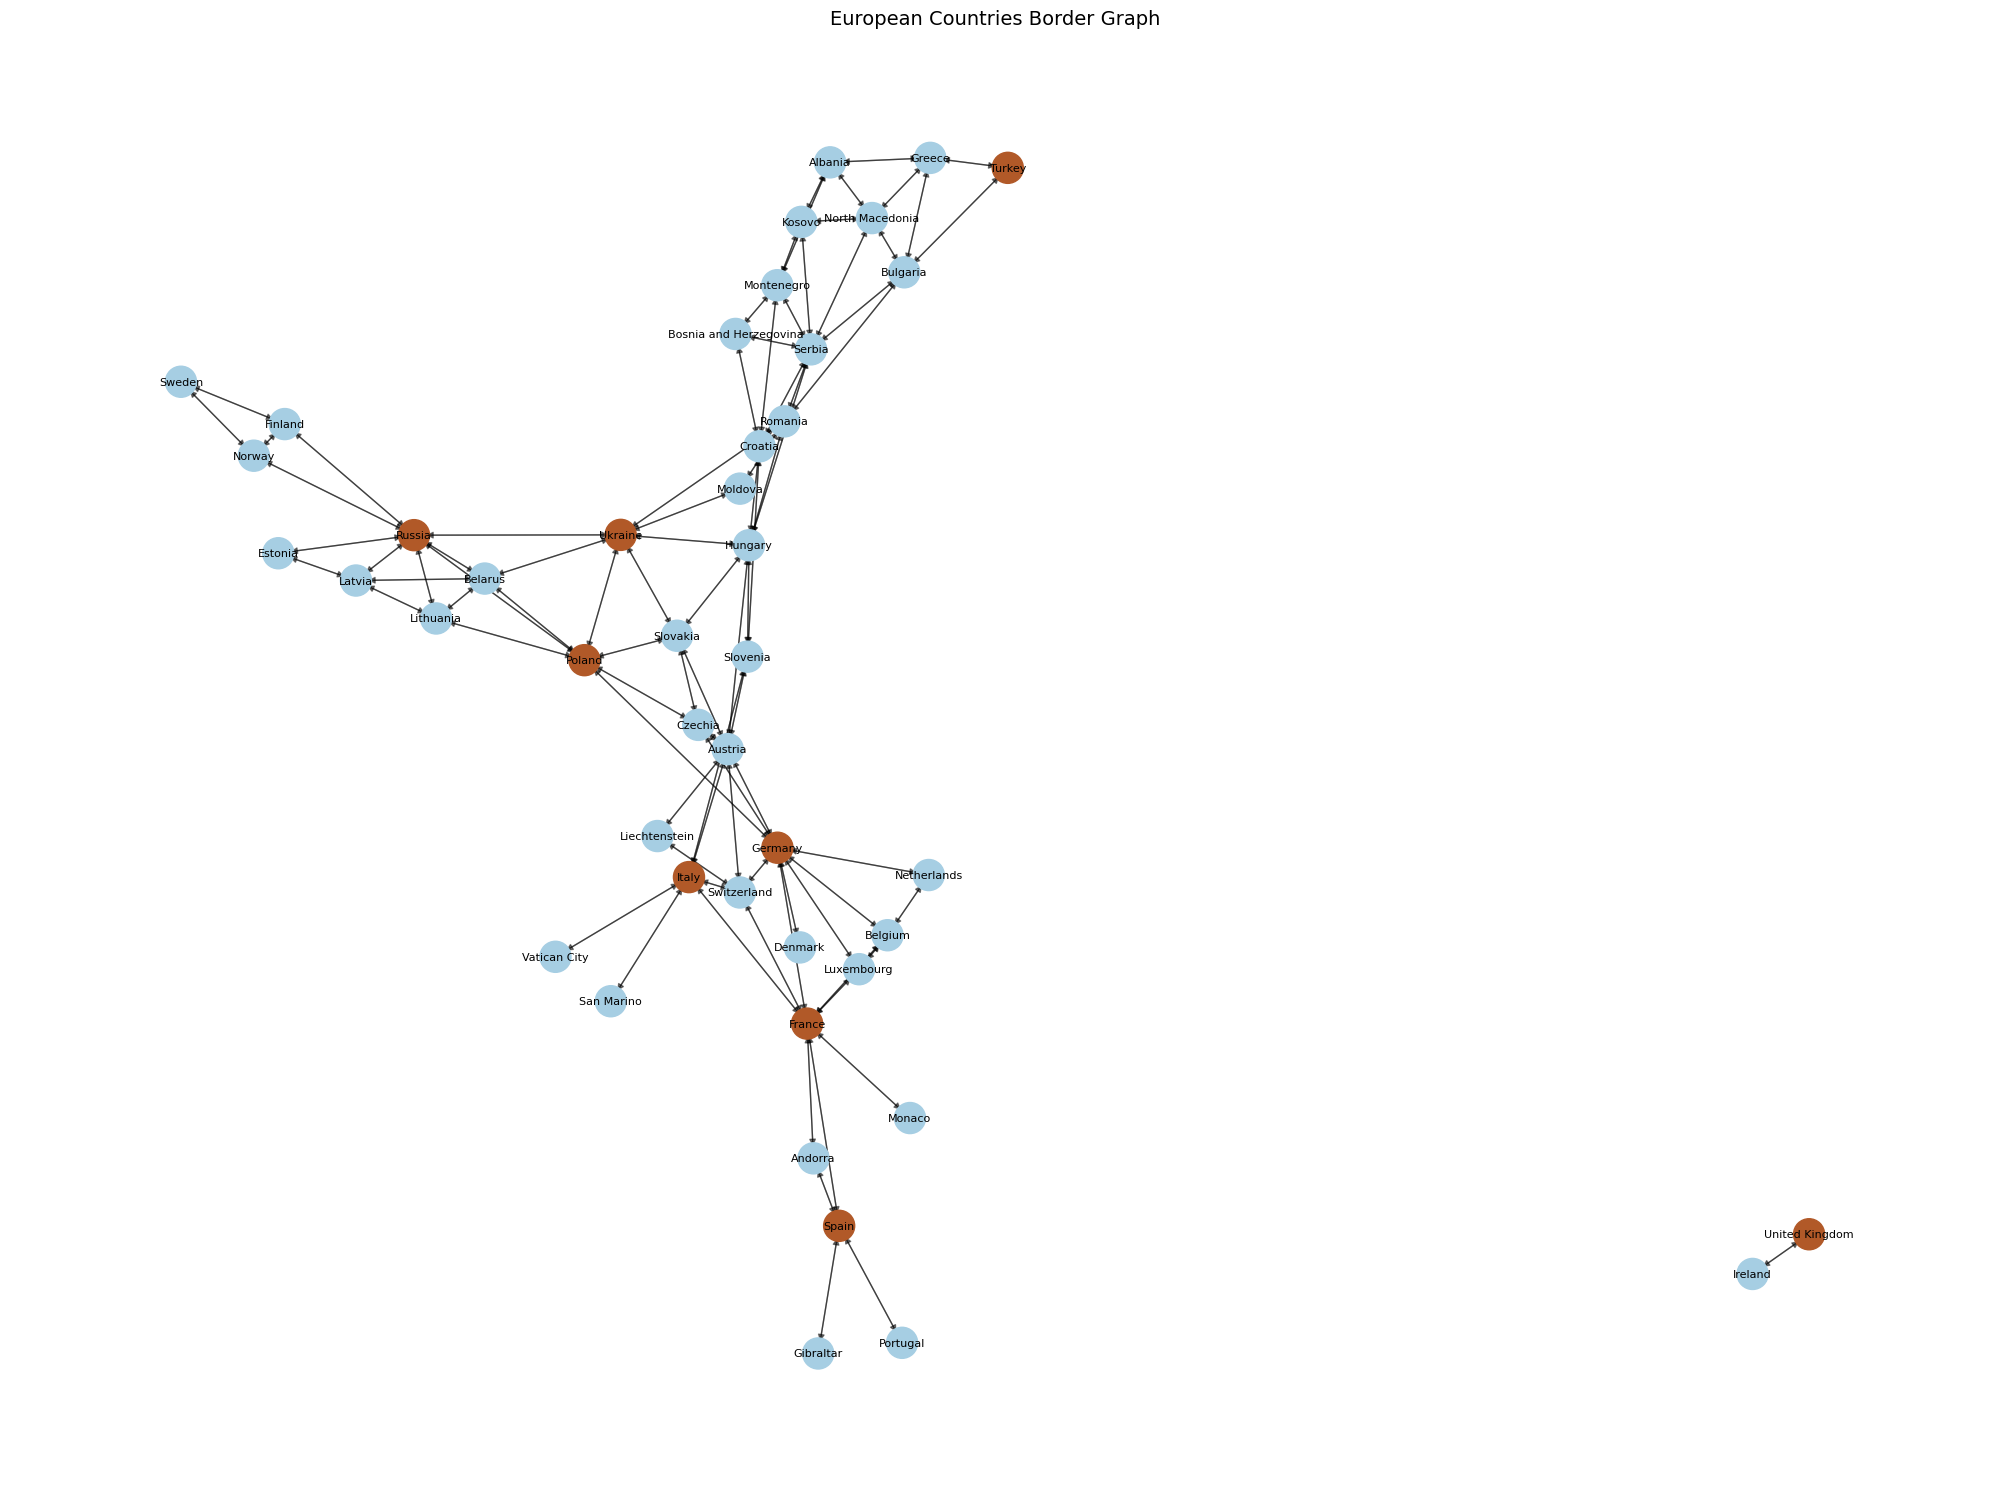

In [ ]:
# Create graph visualization
G = nx.Graph()
for country, neighbors in borders.items():
    if len(neighbors) > 0: # only add countries that have a neighbour
        G.add_node(country, population=populations[country], label = get_label(country))
        for neighbor in neighbors:
            G.add_edge(country, neighbor)

# tranformation into a directed graph
G = nx.to_directed(G)

colors = [G.nodes[node]['label'] for node in list(G.nodes())]

# Draw the graph
plt.figure(figsize=(20, 15))
pos = nx.spring_layout(G, seed=42)
nx.draw_networkx_nodes(G, pos, node_color = colors, cmap=plt.cm.Paired, node_size=500)
nx.draw_networkx_edges(G, pos, alpha=0.5)
nx.draw_networkx_labels(G, pos, font_size=8)
plt.title("European Countries Border Graph", fontsize=14)
plt.axis("off")
plt.tight_layout()

Node labels to integers

In [ ]:
CountryAdjacencyGraph = nx.convert_node_labels_to_integers(G, label_attribute='name')
CountryAdjacencyGraph.nodes(data=True)

NodeDataView({0: {'population': 2.8, 'label': 0, 'name': 'Albania'}, 1: {'population': 10.1, 'label': 0, 'name': 'Greece'}, 2: {'population': 1.8, 'label': 0, 'name': 'Kosovo'}, 3: {'population': 0.62, 'label': 0, 'name': 'Montenegro'}, 4: {'population': 2.0, 'label': 0, 'name': 'North Macedonia'}, 5: {'population': 0.08, 'label': 0, 'name': 'Andorra'}, 6: {'population': 68.0, 'label': 1, 'name': 'France'}, 7: {'population': 47.6, 'label': 1, 'name': 'Spain'}, 8: {'population': 9.1, 'label': 0, 'name': 'Austria'}, 9: {'population': 10.8, 'label': 0, 'name': 'Czechia'}, 10: {'population': 83.3, 'label': 1, 'name': 'Germany'}, 11: {'population': 9.7, 'label': 0, 'name': 'Hungary'}, 12: {'population': 59.0, 'label': 1, 'name': 'Italy'}, 13: {'population': 0.04, 'label': 0, 'name': 'Liechtenstein'}, 14: {'population': 5.4, 'label': 0, 'name': 'Slovakia'}, 15: {'population': 2.1, 'label': 0, 'name': 'Slovenia'}, 16: {'population': 8.7, 'label': 0, 'name': 'Switzerland'}, 17: {'population': 

In [ ]:
CountryAdjacencyGraph.edges

OutEdgeView([(0, 1), (0, 2), (0, 3), (0, 4), (1, 0), (1, 29), (1, 4), (1, 31), (2, 0), (2, 3), (2, 4), (2, 28), (3, 0), (3, 26), (3, 27), (3, 2), (3, 28), (4, 0), (4, 29), (4, 1), (4, 2), (4, 28), (5, 6), (5, 7), (6, 5), (6, 23), (6, 10), (6, 12), (6, 24), (6, 37), (6, 7), (6, 16), (7, 5), (7, 6), (7, 38), (7, 44), (8, 9), (8, 10), (8, 11), (8, 12), (8, 13), (8, 14), (8, 15), (8, 16), (9, 8), (9, 10), (9, 20), (9, 14), (10, 8), (10, 23), (10, 9), (10, 32), (10, 6), (10, 24), (10, 25), (10, 20), (10, 16), (11, 8), (11, 27), (11, 30), (11, 28), (11, 14), (11, 15), (11, 22), (12, 8), (12, 6), (12, 41), (12, 15), (12, 16), (12, 42), (13, 8), (13, 16), (14, 8), (14, 9), (14, 11), (14, 20), (14, 22), (15, 8), (15, 27), (15, 11), (15, 12), (16, 8), (16, 6), (16, 10), (16, 12), (16, 13), (17, 18), (17, 19), (17, 20), (17, 21), (17, 22), (18, 17), (18, 33), (18, 19), (18, 21), (19, 17), (19, 18), (19, 20), (19, 21), (20, 17), (20, 9), (20, 10), (20, 19), (20, 21), (20, 14), (20, 22), (21, 17), 

Data for training

In [ ]:
training_data = [(node[1]['population'], node[1]['label']) for node in list(CountryAdjacencyGraph.nodes(data=True))]
training_data

[(2.8, 0),
 (10.1, 0),
 (1.8, 0),
 (0.62, 0),
 (2.0, 0),
 (0.08, 0),
 (68.0, 1),
 (47.6, 1),
 (9.1, 0),
 (10.8, 0),
 (83.3, 1),
 (9.7, 0),
 (59.0, 1),
 (0.04, 0),
 (5.4, 0),
 (2.1, 0),
 (8.7, 0),
 (9.2, 0),
 (1.9, 0),
 (2.6, 0),
 (37.5, 1),
 (143.4, 1),
 (35.0, 1),
 (11.6, 0),
 (0.67, 0),
 (17.8, 0),
 (3.2, 0),
 (3.9, 0),
 (6.6, 0),
 (6.5, 0),
 (19.0, 0),
 (85.0, 1),
 (5.9, 0),
 (1.3, 0),
 (5.5, 0),
 (5.5, 0),
 (10.6, 0),
 (0.04, 0),
 (0.03, 0),
 (5.1, 0),
 (68.2, 1),
 (0.03, 0),
 (0.0008, 0),
 (2.6, 0),
 (10.3, 0)]

In [ ]:
import torch

# features
x = torch.tensor([item[0] for item in training_data], dtype=torch.float).unsqueeze(1)
x, x.shape

(tensor([[2.8000e+00],
         [1.0100e+01],
         [1.8000e+00],
         [6.2000e-01],
         [2.0000e+00],
         [8.0000e-02],
         [6.8000e+01],
         [4.7600e+01],
         [9.1000e+00],
         [1.0800e+01],
         [8.3300e+01],
         [9.7000e+00],
         [5.9000e+01],
         [4.0000e-02],
         [5.4000e+00],
         [2.1000e+00],
         [8.7000e+00],
         [9.2000e+00],
         [1.9000e+00],
         [2.6000e+00],
         [3.7500e+01],
         [1.4340e+02],
         [3.5000e+01],
         [1.1600e+01],
         [6.7000e-01],
         [1.7800e+01],
         [3.2000e+00],
         [3.9000e+00],
         [6.6000e+00],
         [6.5000e+00],
         [1.9000e+01],
         [8.5000e+01],
         [5.9000e+00],
         [1.3000e+00],
         [5.5000e+00],
         [5.5000e+00],
         [1.0600e+01],
         [4.0000e-02],
         [3.0000e-02],
         [5.1000e+00],
         [6.8200e+01],
         [3.0000e-02],
         [8.0000e-04],
         [2

In [ ]:
y = torch.tensor([item[1] for item in training_data], dtype=torch.float).unsqueeze(1)
y, y.shape

(tensor([[0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [1.],
         [1.],
         [0.],
         [0.],
         [1.],
         [0.],
         [1.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [1.],
         [1.],
         [1.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [1.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [0.],
         [1.],
         [0.],
         [0.],
         [0.],
         [0.]]),
 torch.Size([45, 1]))

In [ ]:
# edges
edge_index = torch.tensor(list(CountryAdjacencyGraph.edges), dtype=torch.long)
edge_index, edge_index.shape

(tensor([[ 0,  1],
         [ 0,  2],
         [ 0,  3],
         [ 0,  4],
         [ 1,  0],
         [ 1, 29],
         [ 1,  4],
         [ 1, 31],
         [ 2,  0],
         [ 2,  3],
         [ 2,  4],
         [ 2, 28],
         [ 3,  0],
         [ 3, 26],
         [ 3, 27],
         [ 3,  2],
         [ 3, 28],
         [ 4,  0],
         [ 4, 29],
         [ 4,  1],
         [ 4,  2],
         [ 4, 28],
         [ 5,  6],
         [ 5,  7],
         [ 6,  5],
         [ 6, 23],
         [ 6, 10],
         [ 6, 12],
         [ 6, 24],
         [ 6, 37],
         [ 6,  7],
         [ 6, 16],
         [ 7,  5],
         [ 7,  6],
         [ 7, 38],
         [ 7, 44],
         [ 8,  9],
         [ 8, 10],
         [ 8, 11],
         [ 8, 12],
         [ 8, 13],
         [ 8, 14],
         [ 8, 15],
         [ 8, 16],
         [ 9,  8],
         [ 9, 10],
         [ 9, 20],
         [ 9, 14],
         [10,  8],
         [10, 23],
         [10,  9],
         [10, 32],
         [10

In [ ]:
# conversion to coo format
edge_index.t().contiguous()

tensor([[ 0,  0,  0,  0,  1,  1,  1,  1,  2,  2,  2,  2,  3,  3,  3,  3,  3,  4,
          4,  4,  4,  4,  5,  5,  6,  6,  6,  6,  6,  6,  6,  6,  7,  7,  7,  7,
          8,  8,  8,  8,  8,  8,  8,  8,  9,  9,  9,  9, 10, 10, 10, 10, 10, 10,
         10, 10, 10, 11, 11, 11, 11, 11, 11, 11, 12, 12, 12, 12, 12, 12, 13, 13,
         14, 14, 14, 14, 14, 15, 15, 15, 15, 16, 16, 16, 16, 16, 17, 17, 17, 17,
         17, 18, 18, 18, 18, 19, 19, 19, 19, 20, 20, 20, 20, 20, 20, 20, 21, 21,
         21, 21, 21, 21, 21, 21, 22, 22, 22, 22, 22, 22, 22, 23, 23, 23, 23, 24,
         24, 24, 25, 25, 26, 26, 26, 27, 27, 27, 27, 27, 28, 28, 28, 28, 28, 28,
         28, 28, 29, 29, 29, 29, 29, 30, 30, 30, 30, 30, 31, 31, 32, 33, 33, 34,
         34, 34, 35, 35, 35, 36, 36, 37, 38, 39, 40, 41, 42, 43, 43, 44],
        [ 1,  2,  3,  4,  0, 29,  4, 31,  0,  3,  4, 28,  0, 26, 27,  2, 28,  0,
         29,  1,  2, 28,  6,  7,  5, 23, 10, 12, 24, 37,  7, 16,  5,  6, 38, 44,
          9, 10, 11, 12, 13, 14, 15

In [ ]:
!pip install -q torch-geometric

In [ ]:
# PyTorch Geometric data structure
from torch_geometric.data import Data

data = Data(x=x, edge_index=edge_index.t().contiguous(), y =y)
data

Data(x=[45, 1], edge_index=[2, 178], y=[45, 1])

In [ ]:
data.num_nodes, data.num_edges, data.num_node_features, data.has_isolated_nodes(), data.has_self_loops(), data.is_directed()

(45, 178, 1, False, False, False)

# Chapter 4: Training / without interaction

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

class MLPClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(1, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.fc(x)

In [ ]:
def show_loss(losses):
  # plotting the loss evolution during training
  plt.plot(losses)
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.title('Training Loss')
  plt.show()

def show_accuracies(accuracies):
  # plotting the accuracy evolution during training
  plt.plot(accuracies)
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.title('Training accuracy')
  plt.show()

MLPClassifier(
  (fc): Sequential(
    (0): Linear(in_features=1, out_features=1, bias=True)
    (1): Sigmoid()
  )
)
Epoch 1/300, Loss: 1.1958, Accuracy: 80.00%
Epoch 10/300, Loss: 0.5799, Accuracy: 71.11%
Epoch 20/300, Loss: 0.5844, Accuracy: 60.00%
Epoch 30/300, Loss: 0.5200, Accuracy: 75.56%
Epoch 40/300, Loss: 0.4781, Accuracy: 100.00%
Epoch 50/300, Loss: 0.4509, Accuracy: 100.00%
Epoch 60/300, Loss: 0.4251, Accuracy: 95.56%
Epoch 70/300, Loss: 0.4017, Accuracy: 100.00%
Epoch 80/300, Loss: 0.3804, Accuracy: 100.00%
Epoch 90/300, Loss: 0.3605, Accuracy: 100.00%
Epoch 100/300, Loss: 0.3422, Accuracy: 100.00%
Epoch 110/300, Loss: 0.3251, Accuracy: 100.00%
Epoch 120/300, Loss: 0.3094, Accuracy: 100.00%
Epoch 130/300, Loss: 0.2947, Accuracy: 100.00%
Epoch 140/300, Loss: 0.2810, Accuracy: 100.00%
Epoch 150/300, Loss: 0.2683, Accuracy: 100.00%
Epoch 160/300, Loss: 0.2565, Accuracy: 100.00%
Epoch 170/300, Loss: 0.2455, Accuracy: 100.00%
Epoch 180/300, Loss: 0.2352, Accuracy: 100.00%
Epoch

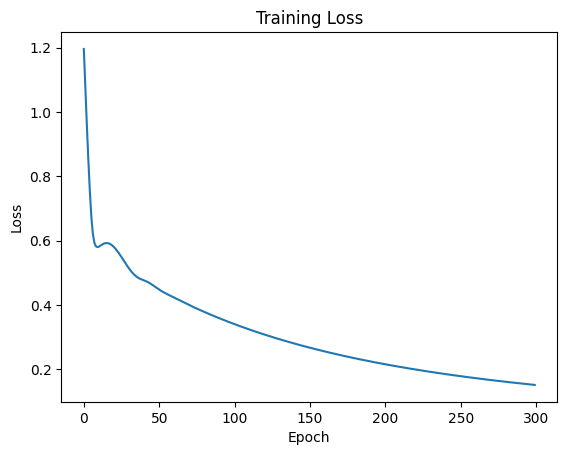

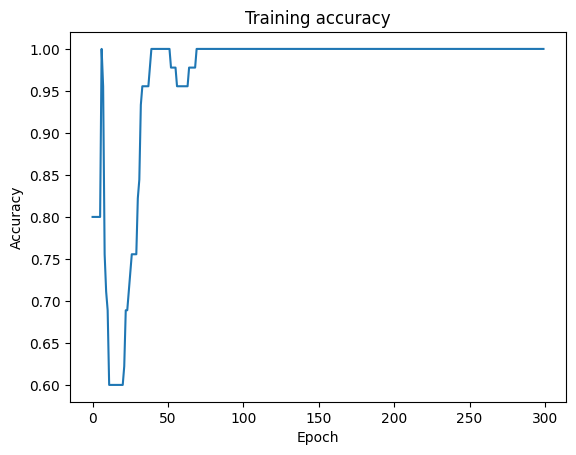

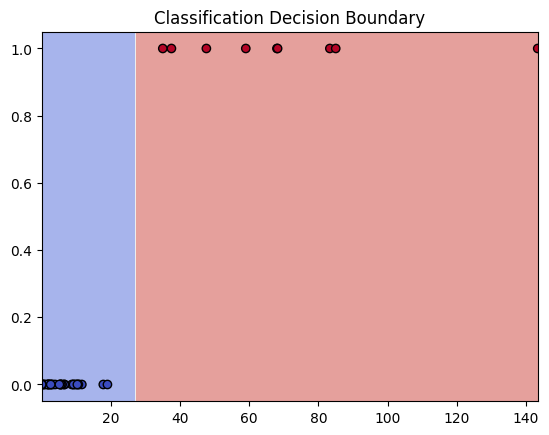

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Train the model
def train_model(model, X, y, epochs=300, lr=0.01): #1e-2
    losses = []
    accuracies = []
    optimizer = optim.Adam(model.parameters(), lr=lr)
    bce = nn.BCELoss()

    for epoch in range(epochs):
        outputs = model(X)
        loss = bce(outputs, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        predicted = torch.round(outputs)
        acc = (predicted == y).float().mean()
        losses.append(loss.item())
        accuracies.append(acc)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            #print(predicted, "-", y)
            print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}, Accuracy: {acc*100:.2f}%")

    show_loss(losses)
    show_accuracies(accuracies)

# Visualize decision boundary
def plot_decision_boundary(model, X, y):
    x_min, x_max = X.min() - 0.0005, X.max() + 0.0005
    y_min, y_max = y.min() - 0.05, y.max() + 0.05
    n_grid_points = 300
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, n_grid_points), np.linspace(y_min, y_max, n_grid_points))

    # prepare input for the model
    x_in = torch.tensor(xx.ravel(), dtype=torch.float32).unsqueeze(1)
    with torch.no_grad():
      y_pred = torch.round(model(x_in)).reshape(xx.shape)
    plt.contourf(xx, yy, y_pred, cmap='coolwarm', alpha=0.5)
    plt.scatter(X, y, c=y, cmap='coolwarm', edgecolors='k')
    plt.title("Classification Decision Boundary")
    plt.show()

normalized_x = (data.x - torch.min(data.x)) / (torch.max(data.x) - torch.min(data.x))
normalized_x

mpl_model101 = MLPClassifier()
print(mpl_model101)
train_model(mpl_model101, data.x, data.y)
plot_decision_boundary(mpl_model101, data.x, data.y)

# Chapter 5: Training / with interaction included

In [ ]:
def get_label(country):
    #print(country, " - ", borders[country])
    neighbors = borders[country]
    #print(populations[country])
    neighb_pops = 0
    for neighbor in neighbors:
        neighb_pops += populations[neighbor]
    return int(neighb_pops > 100)

In [ ]:
get_label("Germany")

In [ ]:
# Create graph visualization
G = nx.Graph()
for country, neighbors in borders.items():
    if len(neighbors) > 0: # only add countries that have a neighbour
        G.add_node(country, population=populations[country], label = get_label(country))
        for neighbor in neighbors:
            G.add_edge(country, neighbor)

G = nx.to_directed(G)

colors = [G.nodes[node]['label'] for node in list(G.nodes())]

# Draw the graph
plt.figure(figsize=(20, 15))
pos = nx.spring_layout(G, seed=42)
nx.draw_networkx_nodes(G, pos, node_color = colors, cmap=plt.cm.Paired, node_size=500)
nx.draw_networkx_edges(G, pos, alpha=0.5)
nx.draw_networkx_labels(G, pos, font_size=8)
plt.title("European Countries Border Graph", fontsize=14)
plt.axis("off")
plt.tight_layout()

In [ ]:
CountryAdjacencyGraph = nx.convert_node_labels_to_integers(G, label_attribute='name')
CountryAdjacencyGraph.nodes(data=True)

In [ ]:
!pip install -q torch-geometric

In [ ]:
import torch
from torch_geometric.data import Data

training_data = [(node[1]['population'], node[1]['label']) for node in list(CountryAdjacencyGraph.nodes(data=True))]

x = torch.tensor([item[0] for item in training_data], dtype=torch.float).unsqueeze(1)
y = torch.tensor([item[1] for item in training_data], dtype=torch.float).unsqueeze(1)
edge_index = torch.tensor(list(CountryAdjacencyGraph.edges), dtype=torch.long)

data2 = Data(x=x, edge_index=edge_index.t().contiguous(), y =y)
data2, data2.num_nodes, data2.num_edges, data2.num_node_features, data2.has_isolated_nodes(), data2.has_self_loops(), data2.is_directed()

In [ ]:
training_data

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

class MLPClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(1, 1),
            nn.ReLU(),
            #nn.Linear(10, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.fc(x)

In [ ]:
def show_loss(losses):
  # plotting the loss evolution during training
  plt.plot(losses)
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.title('Training Loss')
  plt.show()

def show_accuracies(accuracies):
  # plotting the accuracy evolution during training
  plt.plot(accuracies)
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.title('Training accuracy')
  plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Train the model
def train_model(model, X, y, epochs=300, lr=0.01): #1e-2
    losses = []
    accuracies = []
    optimizer = optim.Adam(model.parameters(), lr=lr)
    bce = nn.BCELoss()

    for epoch in range(epochs):
        outputs = model(X)
        loss = bce(outputs, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        predicted = torch.round(outputs)
        acc = (predicted == y).float().mean()
        losses.append(loss.item())
        accuracies.append(acc)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            #print(predicted, "-", y)
            print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}, Accuracy: {acc*100:.2f}%")

    show_loss(losses)
    show_accuracies(accuracies)

# Visualize decision boundary
def plot_decision_boundary(model, X, y):
    x_min, x_max = X.min() - 0.0005, X.max() + 0.0005
    y_min, y_max = y.min() - 0.05, y.max() + 0.05
    n_grid_points = 300
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, n_grid_points), np.linspace(y_min, y_max, n_grid_points))

    # prepare input for the model
    x_in = torch.tensor(xx.ravel(), dtype=torch.float32).unsqueeze(1)
    with torch.no_grad():
      y_pred = torch.round(model(x_in)).reshape(xx.shape)
    plt.contourf(xx, yy, y_pred, cmap='coolwarm', alpha=0.5)
    plt.scatter(X, y, c=y, cmap='coolwarm', edgecolors='k')
    plt.title("Classification Decision Boundary")
    plt.show()

mlp_model = MLPClassifier()
print(mlp_model)
train_model(mlp_model, data2.x, data2.y)
plot_decision_boundary(mlp_model, data2.x, data2.y)

In [ ]:
# https://pytorch-geometric.readthedocs.io/en/2.5.1/cheatsheet/gnn_cheatsheet.html#graph-neural-network-operators
from torch_geometric.nn import SimpleConv
from torch_geometric.nn import GCNConv
from torch_geometric.nn import GraphConv
from torch_geometric.nn import GATConv
import torch.nn.functional as F

# Define GCN model (uses edge information)
class GCNClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.gnc1 = SimpleConv()# GCNConv(1, 1)

        self.fc = nn.Sequential(
            nn.Linear(1, 1),
            nn.Sigmoid())

    def forward(self, x, edge_index):
        # embedding
        h = self.gnc1(x, edge_index)
        h = h.relu()

        # classification
        z = self.fc(h)
        return h, z

In [ ]:
losses = []
accuracies = []
embeddings = []
outputs = []


# Train the model
def train_gcn_model(model, data, y, epochs=1000, lr=0.01):

    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    bce = nn.BCELoss()

    for epoch in range(epochs):
        h, outs = model(data.x, data.edge_index)
        loss = bce(outs, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        #print(outs)
        predicted = torch.round(outs)
        #print(predicted)
        acc = (predicted == y).float().mean()
        losses.append(loss.item())
        accuracies.append(acc)
        embeddings.append(h)
        outputs.append(predicted)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            #print(predicted, "-", y)
            print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}, Accuracy: {acc*100:.2f}%")
    show_loss(losses)
    show_accuracies(accuracies)


gcn_model = GCNClassifier()
print(gcn_model)
train_gcn_model(gcn_model, data2, data2.y)

Showing values from the embedding space

In [ ]:
i = 999

embed = embeddings[i].detach().cpu().numpy()
y = outputs[i].detach().cpu().numpy()

# Plot points
plt.figure(figsize=(10, 2))
plt.scatter(embed[:, 0], y, c=y, cmap=plt.cm.RdYlBu)
plt.show()

In [ ]:
i = 0

embed = embeddings[i].detach().cpu().numpy()
y = outputs[i].detach().cpu().numpy()

# Plot points
plt.figure(figsize=(10, 2))
plt.scatter(embed[:, 0], y, c=y, cmap=plt.cm.RdYlBu)
plt.show()

## Animation

In [ ]:
from torch_geometric.utils import to_networkx

from IPython.display import HTML
from matplotlib import animation
plt.rcParams["animation.bitrate"] = 3000

def animate(i):
    #G = to_networkx(data, to_undirected=True)
    nx.draw_networkx(G,
                    pos=nx.spring_layout(G, seed=0),
                    with_labels=True,
                    node_size=500,
                    node_color=outputs[i].detach().numpy(),
                    cmap="hsv",
                    vmin=-2,
                    vmax=3,
                    width=0.8,
                    edge_color="grey",
                    font_size=14
                    )
    plt.title(f'Epoch {i} | Loss: {losses[i]:.2f} | Acc: {accuracies[i]*100:.2f}%', fontsize=18, pad=20)

fig = plt.figure(figsize=(12, 12))
plt.axis('off')

anim = animation.FuncAnimation(fig, animate, np.arange(0, 1000, 100), interval=500)
html = HTML(anim.to_html5_video())

In [ ]:
display(html)

# Project work



*  Exercice 01: Compute the COO matrix for the Adjacency matrix below per Hand and compare with the results
*  Exercice 02: train a graph neural network to predict house prices, based on the attractiveness of the house of interest and neighbouring houses (the data is purely synthetic)

      1.   Check [pytorch geometric](https://pytorch-geometric.readthedocs.io/en/2.5.1/get_started/introduction.html) for the an introduction to  torch_geometric.data.Data, which you will use as a basic data struture (See Chapter 3: Graph Data Preparation)
      2. Train a multi-layer perceptron first, to see the results
      3. Afterwards, train a GNN. Use a [SimpleConv](https://pytorch-geometric.readthedocs.io/en/2.5.1/generated/torch_geometric.nn.conv.SimpleConv.html#torch_geometric.nn.conv.SimpleConv) layer for the GNN
      4.  This is a ***regression*** problem, so remember to choose the appropriate loss function
      5.  To evaluate your predictions, you can use the evaluation function created below, or use your own. Note that you should create your own evaluation function for the gcn model, based on the template
      6.  Play with different learning rates, optimizers, fully-connected layers, to see the impact

*  Exercice 03 (optional): Think about at least one example, were graph machine learning could be useful as a component in your own scenario

Happy coding!

## COO Matrix Computation

In [ ]:
# Adapted from https://medium.com/@rjnclarke/build-a-graph-neural-network-with-pytorch-geometric-fd7918345fa8
import torch
A = torch.Tensor([
    [0,1,0,0],
    [0,1,1,0],
    [1,0,0,0],
    [1,1,0,1]
])

edge_index = A.nonzero(as_tuple=True)

edge_index_final = torch.stack(edge_index).long()

A, edge_index, edge_index_final

## GNN training

### Generate Graph

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import random

# Set seed for reproducibility
random.seed(42)

# Create an empty graph
G = nx.Graph()

# Add house nodes
num_nodes = 40
G.add_nodes_from(range(num_nodes))

# Add edges randomly (every edge stands for a 'neighbouring' relationship, e.g. the houses are connected by a road and within 1km walking distance of each other)
# Connect each house (= node) to 1-2 other houses (randomly)
for node in G.nodes():
    num_edges = random.randint(1, 2)
    neighbors = random.sample([n for n in G.nodes() if n != node], num_edges)
    for neighbor in neighbors:
        G.add_edge(node, neighbor)

def get_price(house, Graph):
    neighbors = [n for n in Graph.neighbors(house)] # neighbours of the current house
    #print(f"node: {house}, neighbors: {neighbors}")
    neighb_att = [Graph.nodes[n]["h_attractiveness"] for n in neighbors]
    #print(f"attractiveness of the node: {Graph.nodes[house]['attractiveness']}")
    #print(f"attractiveness of the neighbours: {neighb_att}")
    return sum(neighb_att), 2 * sum(neighb_att) + 10

# add attractiveness for each house
for node in G.nodes():
    G.nodes[node]['h_attractiveness'] = random.randint(12, 20)

# add price for each house (in Euro), as a function of attractiveness
for node in G.nodes():
    n_att, price = get_price(node, G)
    G.nodes[node]['n_attractiveness'] = n_att
    G.nodes[node]['price'] = price

G = nx.to_directed(G)

# Visualize the graph
node_colors = [G.nodes[n]['price'] for n in G.nodes()]
fig, ax = plt.subplots(figsize=(10, 8))

nx.draw(
    G,
    with_labels=True,
    node_color=node_colors,
    cmap=plt.cm.coolwarm,
    node_size=300,
    font_size=8
)

plt.title(f"Randomly Generated House Graph ({num_nodes} Nodes)")

cbar = plt.colorbar(
    plt.cm.ScalarMappable(cmap=plt.cm.coolwarm),
    ax=ax,
    label="House Price (€)"
)
plt.show()

### Show feature information about the graph

In [ ]:
# price = 2 * n_attractiveness + 10
G.nodes(data=True)

### Prepare data for training

In [ ]:
!pip install -q torch-geometric

In [ ]:
import torch

training_data = [(node[1]['h_attractiveness'], node[1]['price'], node[1]['n_attractiveness']) for node in list(G.nodes(data=True))]
h_a = torch.tensor([item[0] for item in training_data], dtype=torch.float).unsqueeze(1) # house attractiveness
h_price = torch.tensor([item[1] for item in training_data], dtype=torch.float).unsqueeze(1) # price value
n_a = torch.tensor([item[2] for item in training_data], dtype=torch.float).unsqueeze(1) # neighbour attractiveness
edge_index = torch.tensor(list(G.edges), dtype=torch.long)
edge_index.t().contiguous()

from torch_geometric.data import Data

data = Data(x=h_a, edge_index=edge_index.t().contiguous(), y=h_price)
data, data.num_nodes, data.num_edges, data.num_node_features, data.has_isolated_nodes(), data.has_self_loops(), data.is_directed()

### Evaluation function

In [ ]:
import numpy as np

# evaluate the model using the training values (for the MLP)
def evaluate_model(model, h_a, n_a):

    model.eval()

    true_price = (2 * n_a + 10).numpy().squeeze(1)
    output = model(h_a)

    with torch.no_grad():
      pred_price = output.numpy().squeeze(1)

    p_error = np.abs(pred_price - true_price)
    print(f"Mean price error: {np.mean(p_error):.4f}")

    # error histograms
    plt.figure(figsize=(12, 5))

    plt.hist(p_error, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    plt.title('Error Distribution')
    plt.xlabel('Absolute Error (€)')
    plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()

    # scatter plot of true vs predicted
    plt.figure(figsize=(12, 5))
    plt.scatter(true_price, pred_price, alpha=0.5, label='price', c='blue')
    plt.xlabel("True Price")
    plt.ylabel("Predicted Price")
    plt.plot(true_price, true_price, 'k--', label="Ideal")
    plt.legend()
    plt.title("True vs Predicted Price")
    plt.grid(True)

#evaluate_model(mlp, h_a, n_a)


# TO DO - define evaluation function for the gcn model
def evaluate_gcn_model(gcn_model, h_a, n_a, edge_index):
    gcn_model.eval()

    '''
    Your code here....
    '''